In [1]:
import tensorflow as tf
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import keras
from plot_keras_history import show_history, plot_history
import numpy as np
from keras import layers

In [2]:
def generate_regression_data():
    X, y = make_regression(n_samples=1000, n_features=5, n_informative=3, noise=15)
    
    y = y + 30 * np.sin(X[:, 0])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(X_train)
    x_test_scaled = scaler.transform(X_test)

    return x_train_scaled, x_test_scaled, y_train, y_test

In [3]:
def build_model(input_dim, hidden_layers: list, activation: list | str, type_of_cat):

    if isinstance(activation, str):
        activations = [activation] * len(hidden_layers)
    else:
        activations = activation
    
    model = Sequential()

    model.add(layers.Input(shape=(input_dim, )))
    
    for units, act in zip(hidden_layers, activations):
        model.add(layers.Dense(units, activation=act))
    if type_of_cat == "classification":
        model.add(layers.Dense(1, activation='sigmoid'))
    elif type_of_cat == "regression":
        model.add(layers.Dense(1))
    else:
        print("pick regression or classification")

    return model 

In [4]:
def train_model(model, X_train, y_train, epochs, type_of_cat, verbose = 0):

    if type_of_cat == "classification":
        model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='binary_crossentropy',
        metrics=['accuracy'])
            
    elif type_of_cat == "regression":
        model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss='mse')
    else:
        print("pick regression or classification")
        
    history = model.fit(X_train, y_train, validation_split = 0.2, epochs= epochs)

    return history

In [11]:

def plot_history(history, cat_type: str = "classification", title: str = ""):
    if cat_type == "classification":
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Wykres Loss
        axes[0].plot(history.history['loss'], label='Trening (loss)', color='blue')
        axes[0].plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
        axes[0].set_title(f"{title} - Loss")
        axes[0].set_xlabel('Epoki')
        axes[0].set_ylabel('Loss')
        axes[0].set_yscale('log')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # Wykres Accuracy
        axes[1].plot(history.history['accuracy'], label='Trening (acc)', color='blue')
        axes[1].plot(history.history['val_accuracy'], label='Walidacja (val_acc)', color='red')
        axes[1].set_title(f"{title} - Accuracy")
        axes[1].set_xlabel('Epoki')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)

    elif cat_type == "regression":
        # Dla regresji generujemy pojedynczy, dopasowany wykres
        plt.figure(figsize=(8, 5))
        plt.plot(history.history['loss'], label='Trening (loss)', color='blue')
        plt.plot(history.history['val_loss'], label='Walidacja (val_loss)', color='red')
        plt.title(f"{title} - Loss (MSE)")
        plt.xlabel('Epoki')
        plt.ylabel('Loss')
        plt.yscale('log')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.5)

    else:
        raise ValueError(f"Nieznany typ: '{cat_type}'. Wybierz 'classification' lub 'regression'.")

    plt.tight_layout()
    plt.show()

In [6]:
X_train_scaled, X_test_scaled, y_train, y_test = generate_regression_data()

In [7]:
model = build_model(5, [16], 'relu', type_of_cat="regression")

In [8]:
history = train_model(model, X_train_scaled, y_train, epochs=200, type_of_cat="regression")

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7647.1382 - val_loss: 6084.9814
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7303.7920 - val_loss: 5701.7881
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6688.1431 - val_loss: 5044.2793
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5757.5088 - val_loss: 4116.1704
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4570.3936 - val_loss: 3067.8418
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3313.8501 - val_loss: 2039.0560
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2166.1184 - val_loss: 1232.7067
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1311.2987 - val_loss: 731.1302
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 798.2679 - val_loss: 502.4083
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 572.4855 - val_loss: 423.8541
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 486.1468 - val_loss: 414.1837
Epoc

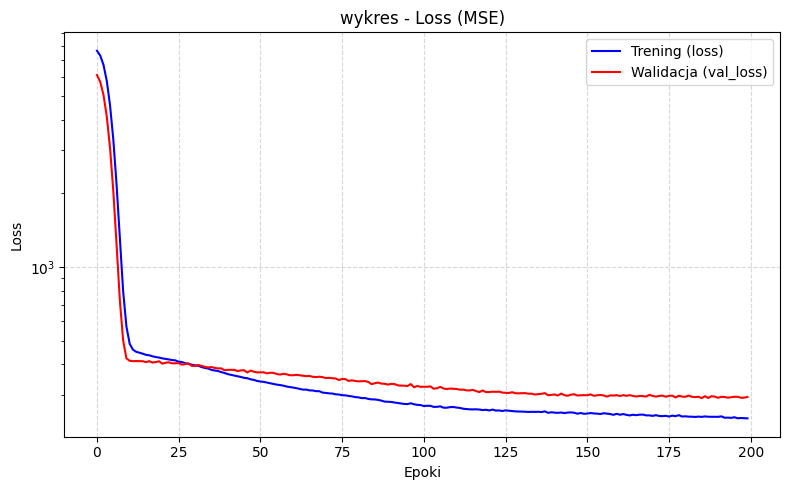

In [13]:
wykres = plot_history(history, "regression", "wykres")

In [14]:
# jak linie sie rozjezdaja to oznacza overfitting

# zadanie 2

In [15]:
dict1 = {"no_hidden": [], "small": [8], "medium": [32], "two_layers": [64, 64], "large": [128, 128, 128]}

def compare_models(configs, data, epochs):

    histories = {}

    X_train_scaled, y_train = data

    for name, layers_num in configs.items():

        model= Sequential()
        model.add(layers.Input(shape=(5, )))
        
        for layer in layers_num:
    
            model.add(layers.Dense(layer, activation='relu'))

        model.add(layers.Dense(1))
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='mse',metrics=['mae'])
        history = model.fit(X_train_scaled, y_train, validation_split = 0.2, verbose=0, epochs= epochs)
        histories[name] = history
        
    return histories

In [16]:
data_xy = (X_train_scaled, y_train)

In [17]:
models = compare_models(dict1, data_xy, epochs=150)

In [18]:
models

{'no_hidden': <keras.src.callbacks.history.History at 0x127d15f90>,
 'small': <keras.src.callbacks.history.History at 0x127d16ad0>,
 'medium': <keras.src.callbacks.history.History at 0x126b80510>,
 'two_layers': <keras.src.callbacks.history.History at 0x127e9f230>,
 'large': <keras.src.callbacks.history.History at 0x12848f0b0>}

In [19]:
models['no_hidden'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [22]:
def to_df(models):
    data = []
    for name, history in models.items():
        mini_data = {"name" :name,
                     "mae" : history.history['mae'][-1],
                     "loss": history.history['loss'][-1],
                     "val_loss": history.history['val_loss'][-1]
                    }
        data.append(mini_data)
    
    df = pd.DataFrame(data)
    return df


In [23]:
df

NameError: name 'df' is not defined

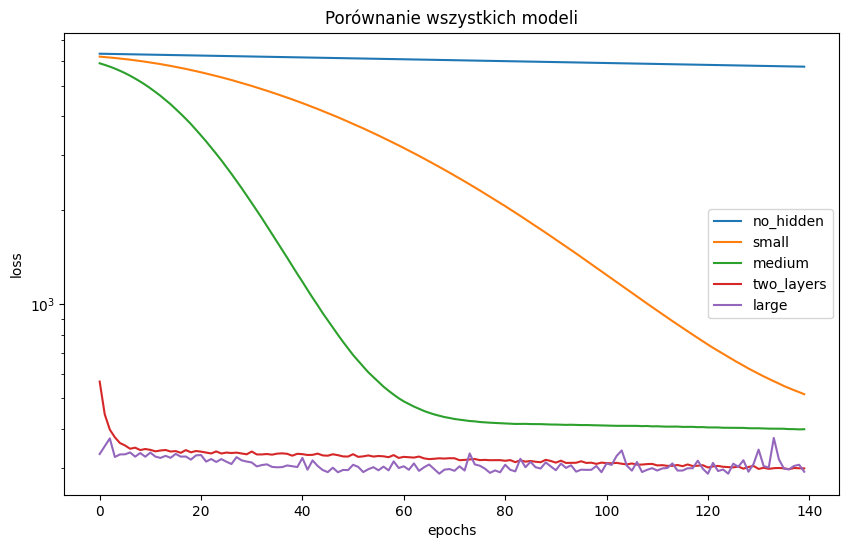

In [24]:
def plot_histories(histories):
    plt.figure(figsize=(10, 6))  

    for name, history in histories.items():  
        plt.plot(history.history['val_loss'][10:], label=name)

    plt.yscale('log')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title("Porównanie wszystkich modeli")
    plt.legend()
    plt.show() 

plot_histories(models)

In [25]:
# najlepiej wyszedl model bez warstw, a najgorzej model large. przeuczenia nie ma. model large jest niestabilny

# zadanie 3 

In [26]:
act_to_test = ['linear', 'sigmoid', 'tanh', 'relu', 'elu']

In [27]:
X_train_scaled_2, X_test_scaled_2, y_train_2, y_test_2 = generate_regression_data()

In [28]:
histories_2 = {}

for act in act_to_test:
    model = Sequential([
        layers.Input(shape=(5,)),
        layers.Dense(32, activation=act),
        layers.Dense(32, activation=act),
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    histories_2[act] = model.fit(
        X_train_scaled_2, 
        y_train_2, 
        validation_split=0.2, 
        verbose=0, 
        epochs=100
    )
histories_2

{'linear': <keras.src.callbacks.history.History at 0x1288a9e10>,
 'sigmoid': <keras.src.callbacks.history.History at 0x128a899d0>,
 'tanh': <keras.src.callbacks.history.History at 0x128163e50>,
 'relu': <keras.src.callbacks.history.History at 0x128162950>,
 'elu': <keras.src.callbacks.history.History at 0x128eb3980>}

In [29]:
histories_2['linear'].history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [30]:
df_2 = to_df(histories_2)
df_2

,name,mae,loss,val_loss
0,linear,12.826185,274.718567,272.793854
1,sigmoid,54.328148,5695.099121,5613.963867
2,tanh,37.968849,3343.867920,3442.150879
3,relu,12.971956,275.328918,281.508789
4,elu,13.203565,284.823669,309.794952


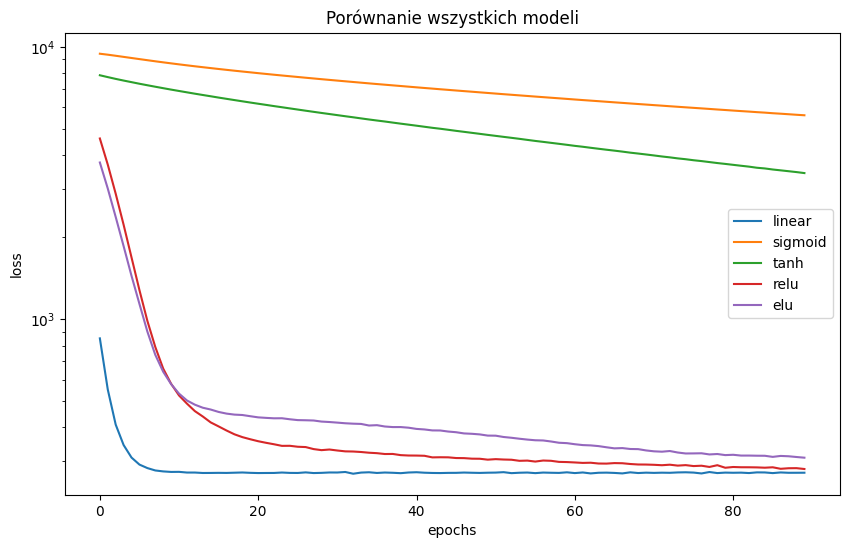

In [31]:
wykres_2 = plot_histories(histories_2)
wykres_2

In [32]:
for act, hist in histories_2.items():
    val_loss, mae = hist.model.evaluate(X_test_scaled_2, y_test_2, verbose=0)
    print(f"{act} mae: {mae}, val_loss: {val_loss}")

linear mae: 13.814905166625977, val_loss: 309.4864807128906
sigmoid mae: 65.09526062011719, val_loss: 8054.89990234375
tanh mae: 49.415977478027344, val_loss: 5109.86083984375
relu mae: 14.344263076782227, val_loss: 338.711181640625
elu mae: 14.087126731872559, val_loss: 329.6617126464844


In [33]:
# model z aktywacja linear uczyl sie najszybciej - osiagnal limit w okolo 5 epoce

# zadanie 4 

In [34]:
from sklearn.datasets import make_classification, make_moons

def generate_classification_data(kind, random_state = 42):
    if kind == "blobs":
        X, y = make_classification(
        n_samples=1000, n_features=2, n_informative=2,
        n_redundant=0, n_clusters_per_class=2, flip_y=0.05, random_state=random_state)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
    elif kind == "moons":
        X, y = make_moons(
        n_samples=1000, noise=0.2, random_state=random_state)

    else:
        raise ValueError("incorrect category")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [35]:
data_2 = generate_classification_data("blobs")
X_train_scaled_3, X_test_scaled_3, y_train_3, y_test_3 = data_2

In [36]:
data_3 = generate_classification_data("moons")
X_train_scaled_4, X_test_scaled_4, y_train_4, y_test_4 = data_3

In [37]:
def plot_decision_boundary(model, X, y, title: str = "Granica decyzyjna"):
    # 1. Wyznaczenie zakresu osi z marginesem
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # 2. Tworzenie gęstej siatki punktów (200x200)
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 3. Predykcja dla całej siatki
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid, verbose=0)
    
    # Przekształcenie prawdopodobieństw na klasy 0/1 i format siatki
    preds = (preds > 0.5).astype(int).reshape(xx.shape)

    # 4. Rysowanie tła i rzeczywistych punktów
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, preds, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=30)
    
    plt.title(title)
    plt.xlabel("Cecha 1 (X1)")
    plt.ylabel("Cecha 2 (X2)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

In [38]:
# --- MOONS ---
m_moons_brak = build_model(2, [], 'relu', 'classification')
m_moons_maly = build_model(2, [8], 'relu', 'classification')
m_moons_gleb = build_model(2, [32, 32], 'relu', 'classification')

hist_moons_no = train_model(m_moons_brak, X_train_scaled_4, y_train_4, 100, 'classification')
hist_moons_one = train_model(m_moons_maly, X_train_scaled_4, y_train_4, 100, 'classification')
hist_moons_two = train_model(m_moons_gleb, X_train_scaled_4, y_train_4, 100, 'classification')

# --- BLOBS ---
m_blobs_brak = build_model(2, [], 'relu', 'classification')
m_blobs_maly = build_model(2, [8], 'relu', 'classification')
m_blobs_gleb = build_model(2, [32, 32], 'relu', 'classification')

hist_blobs_no = train_model(m_blobs_brak, X_train_scaled_3, y_train_3, 100, 'classification')
hist_blobs_one = train_model(m_blobs_maly, X_train_scaled_3, y_train_3, 100, 'classification')
hist_blobs_two = train_model(m_blobs_gleb, X_train_scaled_3, y_train_3, 100, 'classification')

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8219 - loss: 0.3678 - val_accuracy: 0.8188 - val_loss: 0.3620
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8391 - loss: 0.3460 - val_accuracy: 0.8250 - val_loss: 0.3433
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8438 - loss: 0.3316 - val_accuracy: 0.8375 - val_loss: 0.3280
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8516 - loss: 0.3199 - val_accuracy: 0.8375 - val_loss: 0.3174
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3123 - val_accuracy: 0.8438 - val_loss: 0.3093
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8672 - loss: 0.3060 - val_accuracy: 0.8438 - val_loss: 0.3028
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8703 - loss: 0.3014 - val_accuracy: 0.8500 - val_loss: 0.2979
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8703 - loss: 0.2982 - val_accuracy: 0.8500 - v

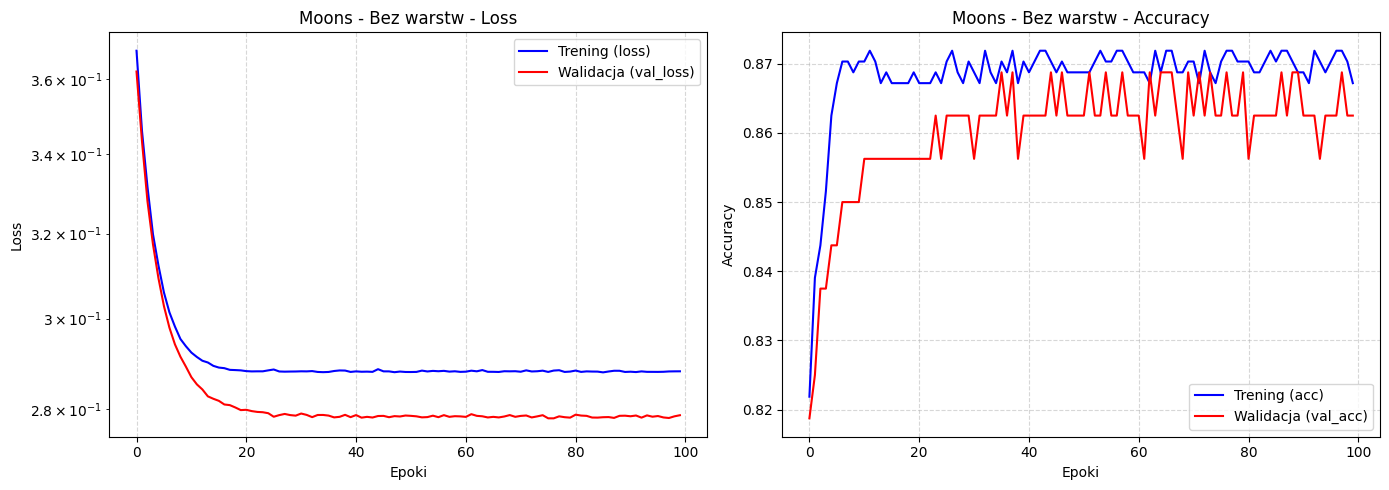

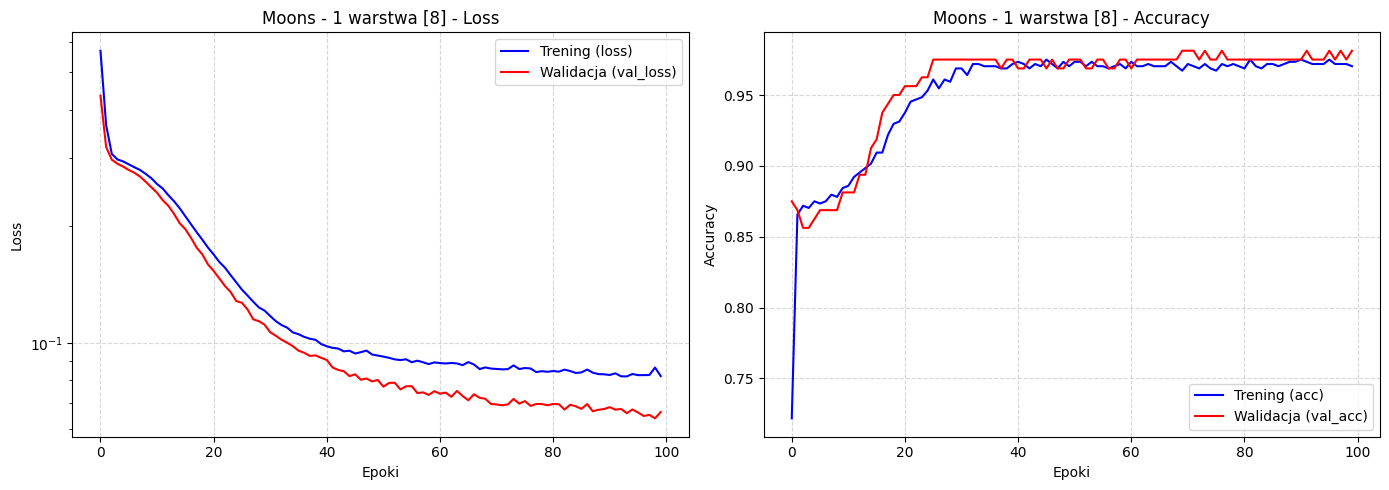

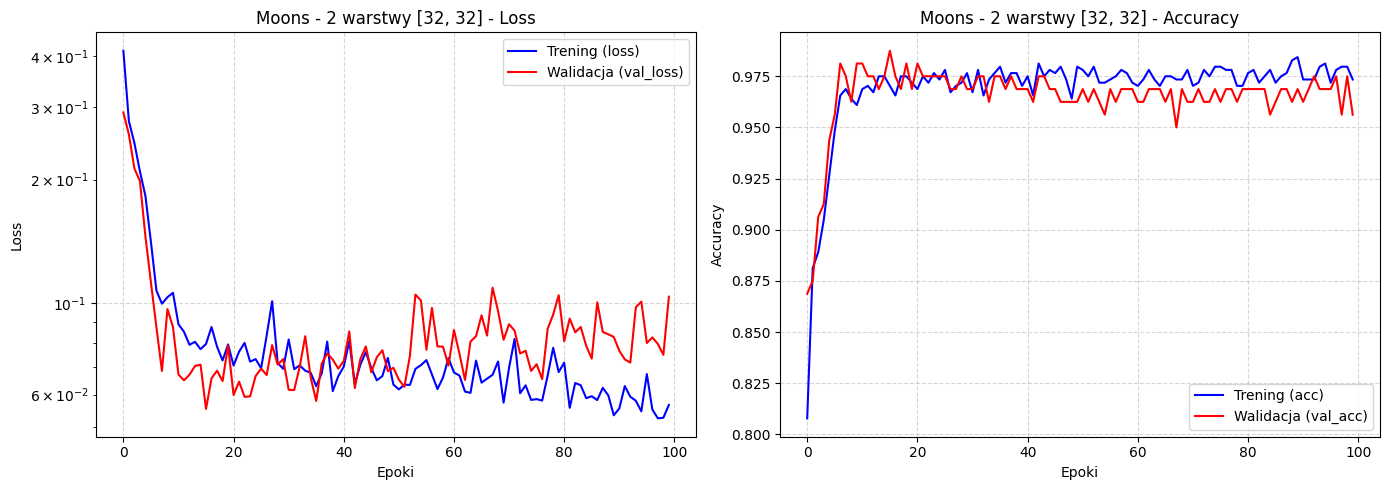

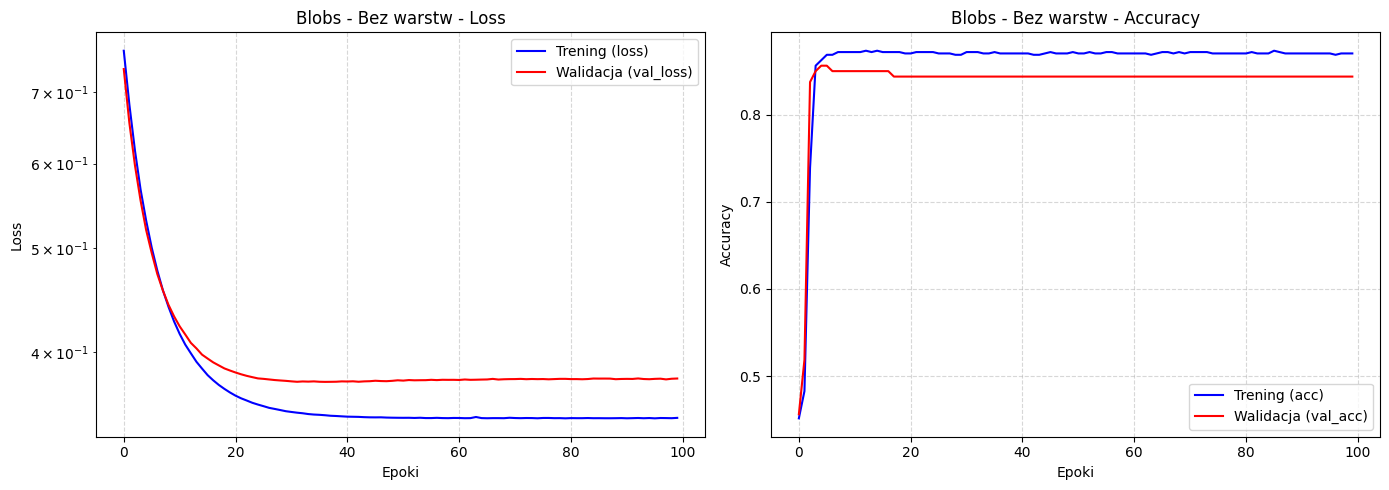

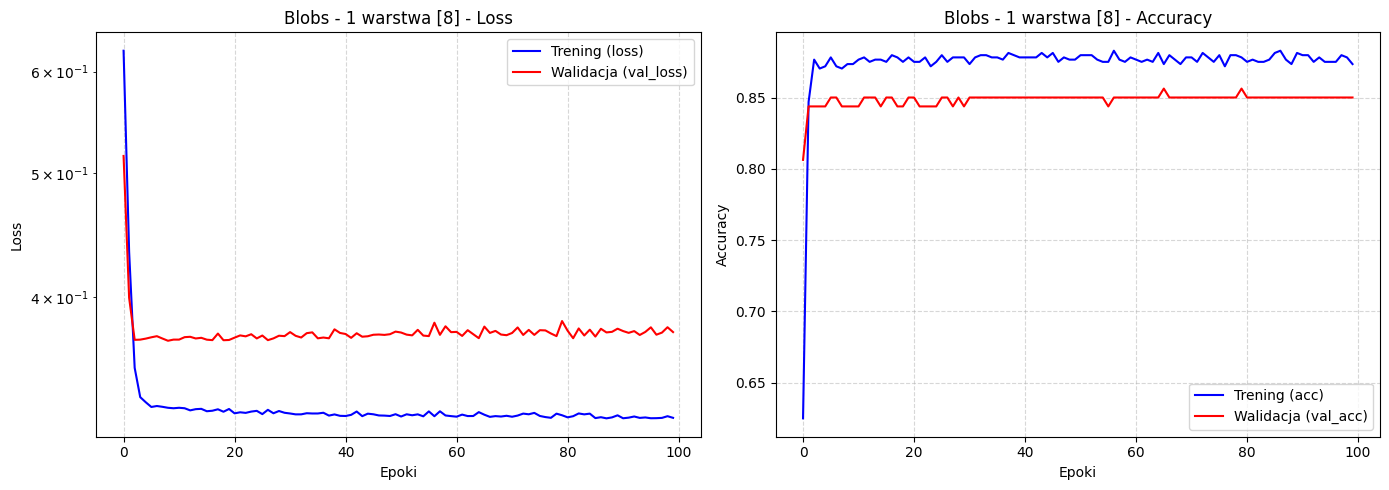

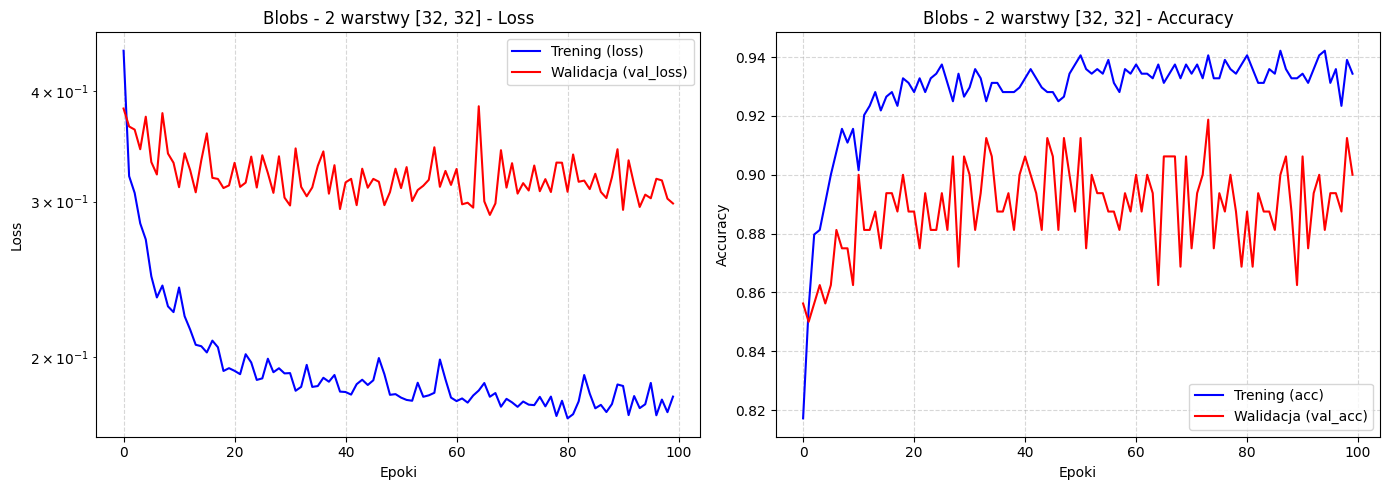

In [39]:
histories = {
    "Moons - Bez warstw": hist_moons_no,
    "Moons - 1 warstwa [8]": hist_moons_one,
    "Moons - 2 warstwy [32, 32]": hist_moons_two,
    "Blobs - Bez warstw": hist_blobs_no,
    "Blobs - 1 warstwa [8]": hist_blobs_one,
    "Blobs - 2 warstwy [32, 32]": hist_blobs_two,
}

for title, hist in histories.items():
    plot_history(hist, title=title)

In [40]:
# model moons bez warstwy nie radzi sobie poniewaz rysuje prosta linie a dane maja ksztalty pierscieni
# modele nie osiagna 100 % skutecznosci poniewaz jest dodane 5 procent szumu

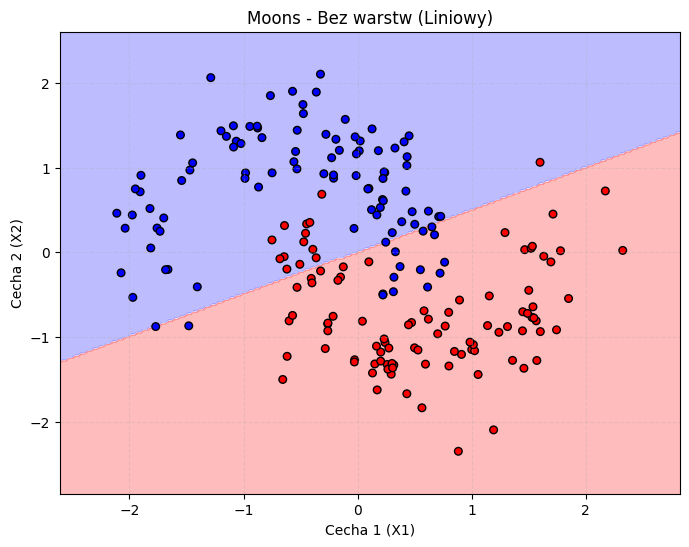

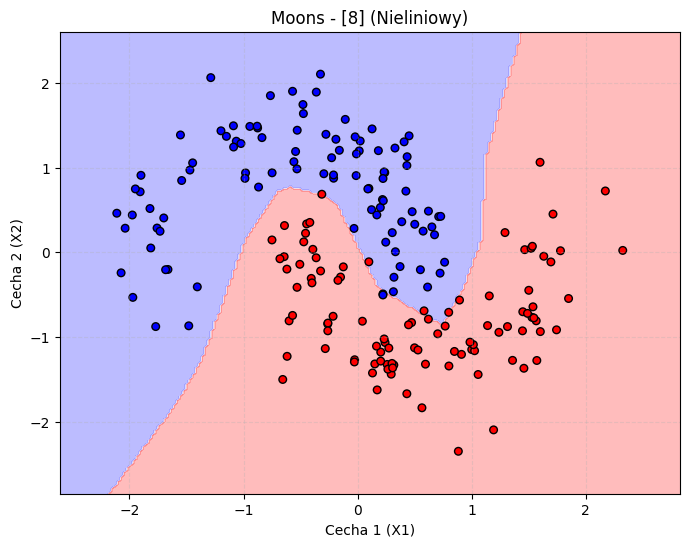

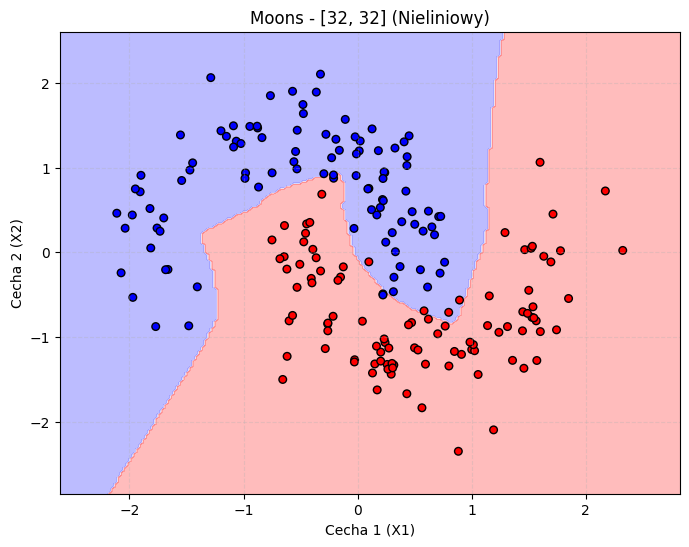

In [41]:
# Zobaczysz prostą kreskę przecinającą dane:
plot_decision_boundary(m_moons_brak, X_test_scaled_4, y_test_4, title="Moons - Bez warstw (Liniowy)")

plot_decision_boundary(m_moons_maly, X_test_scaled_4, y_test_4, title="Moons - [8] (Nieliniowy)")
# Zobaczysz granicę w kształcie litery S, która idealnie omija księżyce:
plot_decision_boundary(m_moons_gleb, X_test_scaled_4, y_test_4, title="Moons - [32, 32] (Nieliniowy)")

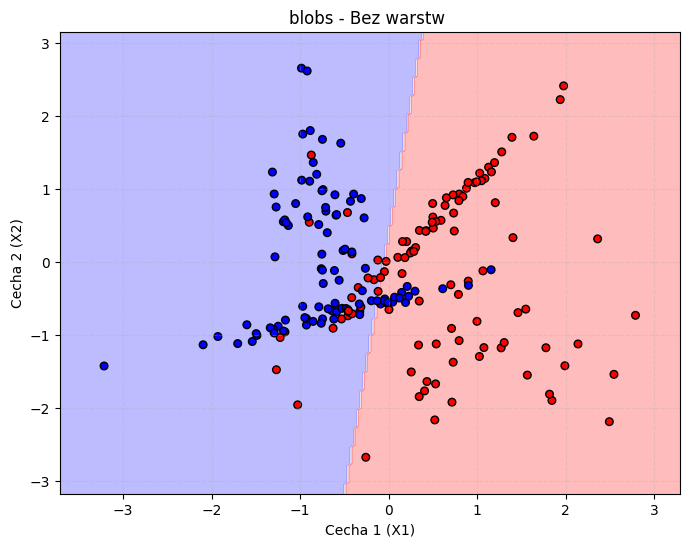

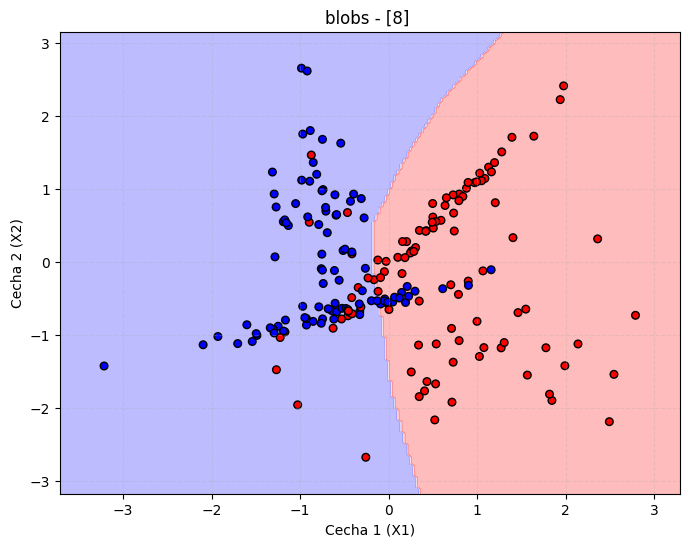

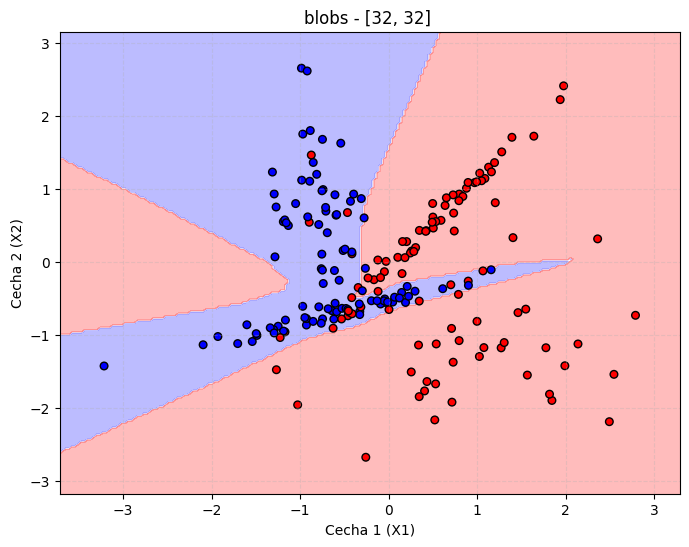

In [42]:
plot_decision_boundary(m_blobs_brak, X_test_scaled_3, y_test_3, title="blobs - Bez warstw ")

plot_decision_boundary(m_blobs_maly, X_test_scaled_3, y_test_3, title="blobs - [8] ")
plot_decision_boundary(m_blobs_gleb, X_test_scaled_3, y_test_3, title="blobs - [32, 32] ")

# zadanie 5

In [48]:
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
X_5, y_5 = make_classification(n_samples=3000, n_features=10, n_informative=5, n_classes=4, class_sep=1.0)

X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(X_5, y_5, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled_5 = scaler.fit_transform(X_train_5)
X_test_scaled_5 = scaler.transform(X_test_5)

In [53]:
model_5 = Sequential([
    layers.Input(shape = (10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')])


model_5.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss',        # metryka do obserwacji
    patience=10,               # ile epok bez poprawy czekamy przed przerwaniem
    restore_best_weights=True  # cofa wagi do najlepszej epoki 
)

history_5 = model_5.fit(
        X_train_scaled_5, 
        y_train_5, 
        validation_split=0.2, 
        verbose=0, 
        callbacks=[early_stop],
        epochs=300
    )
history_5

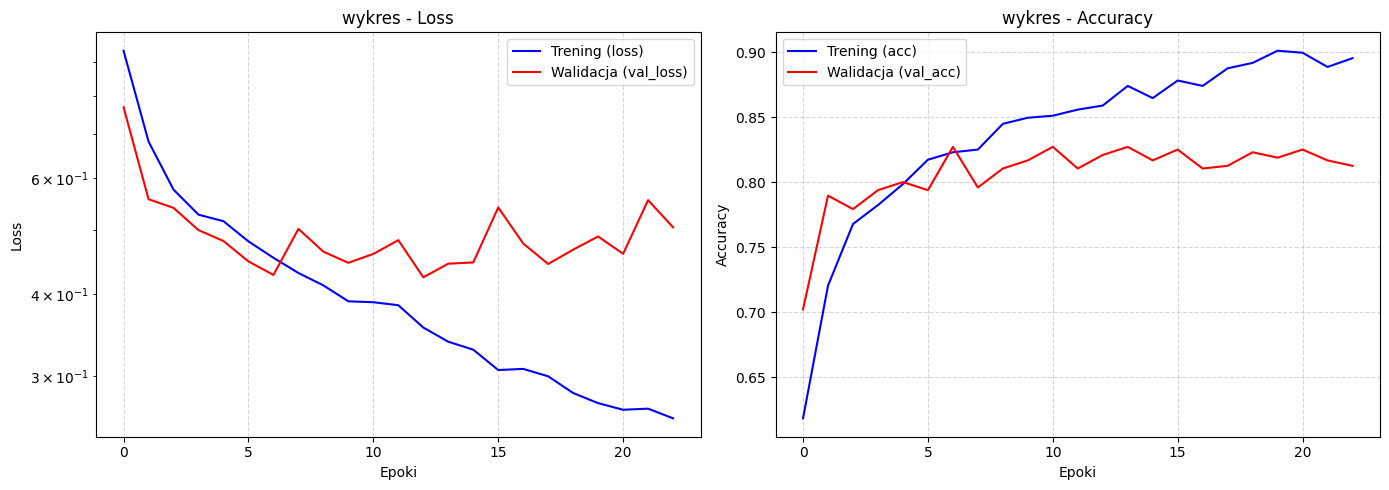

In [54]:
plot_history(history_5, cat_type = "classification", title = "wykres")

In [55]:
len(history_5.history['loss'])

23

In [56]:
model_6 = Sequential([
    layers.Input(shape = (10,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')])


model_6.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy'])

history_6 = model_6.fit(
        X_train_scaled_5, 
        y_train_5, 
        validation_split=0.2, 
        verbose=0, 
        epochs=300
    )
history_6

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

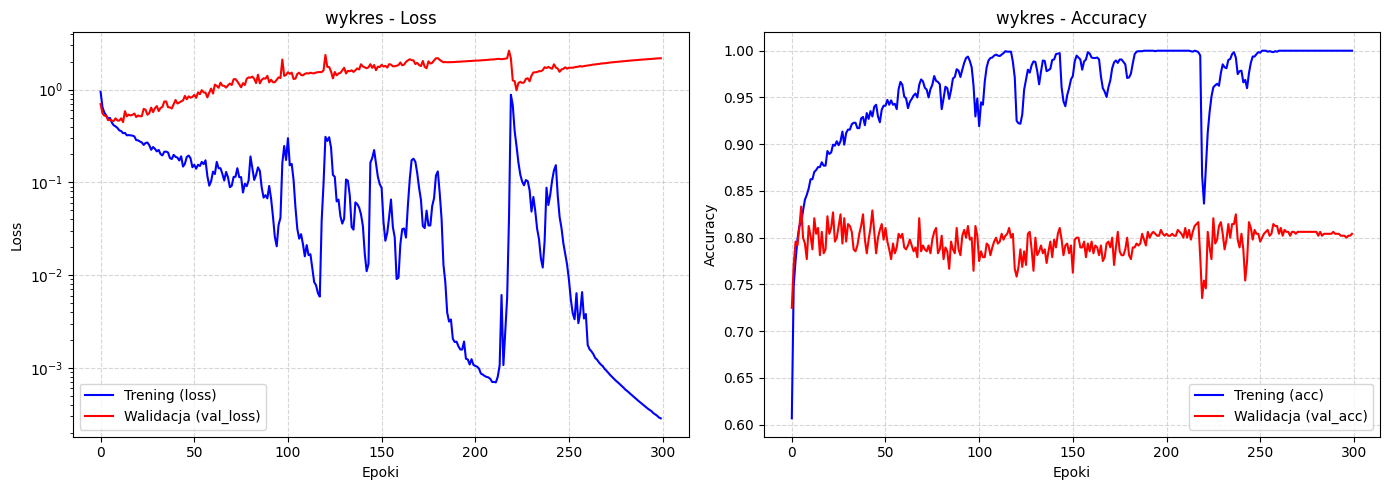

In [60]:
plot_history(history_6, cat_type = "classification", title = "wykres")

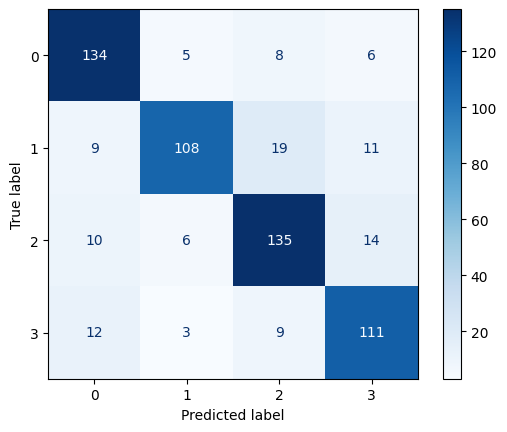

0.8133333333333334

In [66]:
def evaluate_classifier(model, X_test, y_test):
    
    y_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_probs, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.show()

    return acc
model_5_acc = evaluate_classifier(model_5, X_test_scaled_5, y_test_5)
model_5_acc

Early Stopping: Przerywa trening automatycznie w momencie, gdy model przestaje robić postępy na danych walidacyjnych (val_loss), zapobiegając przeuczeniu (overfitting) i marnowaniu czasu.

Parametr patience (bufor cierpliwości): To nie „długość przeuczenia”, lecz liczba kolejnych epok bez poprawy rekordu, jakie dajesz modelowi, zanim trening zostanie przerwany.

In [67]:
# model najczesciej myli klase 1 z klasa 2 